# Проект. Исследование стартапов

- Автор: Козлова Екатерина
- Дата: 18.02.2026 - 20.02.2026

## Введение

**Цель проекта** - провести комплексный анализ исторических данных о финансировании стартапов, чтобы выявить ключевые закономерности привлечения инвестиций и оценить перспективы выхода финансовой компании на рынок.

**Задачи проекта:**
1. Загрузка данных и первичное знакомство с ними.
2. Предобработка данных, включая проверку корректности данных, их типов, наличия или отсуствия пропусков.
3. Проведение исследовательского анализа данных.
4. Подготовка основных выводов и рекомендаций.

### Содержимое проекта

* [Знакомство с данными: загрузка и предобработка](#1bullet) 
* [Инжиниринг признаков](#2bullet)
* [Работа с выбросами и анализ](#3bullet)
* [Анализ динамики](#4bullet)
* [Итоговый вывод и рекомендации](#5bullet)

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

Для корректной последующей работы загрузим необходимые библиотеки.

In [1]:
!pip install phik -U

     |████████████████████████████████| 677 kB 1.7 MB/s eta 0:00:01


In [2]:
# Загрузка библиотек для работы с датафреймами
import pandas as pd

# Загрузка библиотек для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка библиотек для расчета коэффициента корреляции
from phik import phik_matrix

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [3]:
inv_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [4]:
inv_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
ret_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [7]:
ret_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
ret_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp_1 = ret_df.copy() 
len(temp_1)

15

In [10]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp_2 = inv_df.copy() 
len(temp_2)

54294

Выведите информацию, которая необходима для принятия решений о предобработке.

Датафрейм inv_df содержит 54 294 строки и 40 столбцов. Представленные данные в целом соответствуют ожидаемой структуре (название компании, ссылка на сайт компании, категории, в которых работает компания, основной рынок или отрасль компании и т.д.). По представленному датафрейму можно отметить следующее:
1. Во всех столбцах есть пропуски. Столбцы с самым большим количеством пропусков: state_code, city, region, country_code, name, participants, founded_at, founded_month, founded_quarter, founded_year.
2. Даты в формате object. Столбцы founded_at, first_funding_at и др. хранятся как строки. Их нужно преобразовать в datetime.
3. Столбец funding_total_usd лучше преобразовать в числовой тип (float64).

Датафрейм ret_df содержит 15 строк и 14 столбцов. Пропусков нет — все столбцы содержат 15 заполненных значений

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [11]:
inv_df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Удалим пробелы в названиях столбцов и приведем названия столбцов к snake case

In [12]:
inv_df.columns = inv_df.columns.str.lower().str.strip()
inv_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [13]:
ret_df.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Удалим пробелы в названиях столбцов и приведем названия столбцов к snake case

In [14]:
ret_df.columns = ret_df.columns.str.lower().str.strip()
print(ret_df.columns)

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')


Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [15]:
inv_df['funding_total_usd'] = inv_df['funding_total_usd'].str.replace(',', '')
inv_df['funding_total_usd'] = inv_df['funding_total_usd'].str.replace('-', '')
inv_df['funding_total_usd'] = inv_df['funding_total_usd'].str.strip()
inv_df['funding_total_usd'] = pd.to_numeric(inv_df['funding_total_usd'])
inv_df['funding_total_usd'].unique

<bound method Series.unique of 0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64>

In [16]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     40907 non-null  float64
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [17]:
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
for col in date_columns:
    inv_df[col] = pd.to_datetime(inv_df[col], errors='coerce')
print(inv_df[date_columns].dtypes)

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object


В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

Для начала посчитаем абсолютное и относительное количество пропусков для каждого столбца.

In [18]:
inv_df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
market                   8817
funding_total_usd       13387
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15741
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4866
mid_funding_at          24006
last_funding_at          4862
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_a                  4856
round_b   

In [19]:
inv_df.isna().sum() / len(inv_df) * 100

name                     8.945740
homepage_url            15.296350
category_list           16.239363
market                  16.239363
funding_total_usd       24.656500
status                  11.364055
country_code            18.655837
state_code              44.448742
region                  18.655837
city                    20.208494
funding_rounds           8.943898
participants            43.874093
founded_at              28.992154
founded_month           29.122923
founded_quarter         29.122923
founded_year            28.990312
first_funding_at         8.962316
mid_funding_at          44.214830
last_funding_at          8.954949
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt 

In [20]:
for column_name in ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']:
    print(f"Колонка: {column_name}")
    
    unique_values = inv_df[column_name].unique()
    print(f"Уникальные значения: {unique_values}")
    
    unique_count = inv_df[column_name].nunique()
    print(f"Количество уникальных значений: {unique_count}")

Колонка: name
Уникальные значения: ['Harvard University' 'University of New Brunswick' 'DuPont' ...
 'DigiByte' 'Xeltis' 'Logovers']
Количество уникальных значений: 49350
Колонка: homepage_url
Уникальные значения: ['http://harvard.edu' 'http://www.unb.ca' 'http://www.dupont.com' ...
 'http://digibyte.co' 'http://xeltis.com' 'http://www.logovers.com/']
Количество уникальных значений: 45850
Колонка: category_list
Уникальные значения: ['|Education|' nan
 '|Business Services|Agriculture|Automotive|Investment Management|' ...
 '|Medical|Information Services|Information Technology|'
 '|Mining Technologies|' '|Incubators|Designers|Entrepreneur|Startups|']
Количество уникальных значений: 16675
Колонка: market
Уникальные значения: [' Education ' nan ' Business Services ' ' Social Media '
 ' Hardware + Software ' ' Biotechnology ' ' Hardware + Software'
 ' Utilities ' ' Hospitality ' ' Enterprise Software ' ' Manufacturing '
 ' Pharmaceuticals ' 'Finance' 'Shipping' ' Finance ' ' Design '
 ' Non

In [21]:
inv_df.duplicated().sum()

4855

In [22]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [23]:
inv_df = inv_df.copy()
inv_df['market'] = (
    inv_df['market']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
)

print(inv_df[inv_df['market'] == 'software']['market'].value_counts())

software    5489
Name: market, dtype: int64


Заполнять пропуски в текстовых столбцах пока не вижу целесообразным, т.к. их достаточно много и они могут исказить дальнейший анализ. Единственное, что сделаем - уберем пробелы, приведем к единому регистру и удалим пустые значения в столбце market

In [24]:
df_cleaned = inv_df.dropna(subset=['market']).copy()
df_cleaned['market'] = df_cleaned['market'].str.strip()  # Убираем пробелы
df_cleaned['market'] = df_cleaned['market'].str.title()  # Приводим к единому регистру
df_cleaned = df_cleaned.dropna(subset=['market'])  # Удаляем пустые значения

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [25]:
for column_name in ['funding_total_usd']:
    print(f"Колонка: {column_name}")
    
    unique_values = inv_df[column_name].unique()
    print(f"Уникальные значения: {unique_values}")
    
    unique_count = inv_df[column_name].nunique()
    print(f"Количество уникальных значений: {unique_count}")
    
    # Проверим пропуски и нулевые значения
    print(f"Пропусков (NaN): {inv_df[column_name].isna().sum()}")
    print(f"Нулевых значений: {(inv_df[column_name] == 0).sum()}")

Колонка: funding_total_usd
Уникальные значения: [9.000000e+07 2.000000e+06 9.000000e+06 ... 5.897100e+04 7.216365e+06
 5.602480e+05]
Количество уникальных значений: 14616
Пропусков (NaN): 13387
Нулевых значений: 0


In [26]:
display(inv_df['funding_total_usd'].describe())

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Удалим пропуски в funding_total_usd

In [27]:
df_cleaned = inv_df.dropna(subset=['funding_total_usd']).copy()

In [28]:
# Проверяем итоговый размер датафрейма
print(f"Итоговый размер датафрейма: {len(df_cleaned)}")

# Проверяем оставшиеся пропуски
print(df_cleaned.isna().sum())

# Базовая статистика по funding_total_usd
print(df_cleaned['funding_total_usd'].describe())

Итоговый размер датафрейма: 40907
name                        1
homepage_url             2314
category_list            2503
market                   2503
funding_total_usd           0
status                   1105
country_code             3819
state_code              15288
region                   3819
city                     4505
funding_rounds              0
participants            13576
founded_at               8707
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            2
mid_funding_at          13676
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [29]:
print(f"Пропусков до заполнения: {df_cleaned['mid_funding_at'].isna().sum()}")

Пропусков до заполнения: 13676


In [30]:
# Заполняем пропуски серединой интервала
df_cleaned['mid_funding_at'] = df_cleaned['mid_funding_at'].combine_first(
    (df_cleaned['first_funding_at'] + 
     (df_cleaned['last_funding_at'] - df_cleaned['first_funding_at']) / 2)
)

# Оцениваем результат
remaining_missing = df_cleaned['mid_funding_at'].isna().sum()
print(f"Пропусков после заполнения: {remaining_missing}")

Пропусков после заполнения: 1


In [31]:
problematic_row = df_cleaned[df_cleaned['mid_funding_at'].isna()]
print(problematic_row[['first_funding_at', 'last_funding_at', 'mid_funding_at']])

      first_funding_at last_funding_at mid_funding_at
33041              NaT      2014-09-25            NaT


Мы видим, что 1 оставшийся пропуск возник из-за того, что не заполнен столбец first_funding_at, что делает невозможным расчет среднего интервала. Оставим данную строку без изменений, в случае необходимости обработаем её ниже

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [32]:
# Проверим сколько удалено строк датасета
a, b = len(temp_2), len(df_cleaned)
len(temp_2)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 54294 
 Осталось строк в датасете после обработки 40907 
 Удалено строк в датасете после обработки 13387 
 Процент потерь 24.66


В предварительной обработке данныъх участвовал датафрейм inv_df, содержащий информацию о компаниях и состоявшемся финансировании (датафрейм ret_df в обработке не участвовал, т.к. во время знакомства с ним было определено, что в нем нет пропусков или некорректных значений).
После предобработки мы видим, что сохранено значительное количество данных (75.34%).Основной целевой показатель funding_total_usd теперь без пропусков (пропуски в остальных столбцах остались без обработки, т.к. предварительно это не повлияет на дальнейший анализ). 
Данные можно считать достаточными для решения основных задач проекта, так как:
- Сохранено более 75% исходных данных
- ючевые финансовые показатели очищены от пропусков

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

Определим группы компаний по критериям:

In [33]:
# Создаем колонку с разницей между первым и последним финансированием
df_cleaned['funding_duration'] = (df_cleaned['last_funding_at'] - df_cleaned['first_funding_at']).dt.days

# Разделим компании на категории
conditions = [
    (df_cleaned['funding_rounds'] == 1),  # Единичное финансирование (был всего один раунд)
    (df_cleaned['funding_duration'] <= 365),  # Срок финансирования до года
    (df_cleaned['funding_duration'] > 365)  # Срок финансирования более года
]

choices = ['Единичное финансирование', 'До года', 'Более года']

df_cleaned['funding_group'] = np.select(conditions, choices, default=np.nan)

# Обработаем NaN значения
df_cleaned['funding_group'] = df_cleaned['funding_group'].fillna('Не определено')

# Проверим распределение по группам
print("Распределение по группам:")
print(df_cleaned['funding_group'].value_counts(dropna=False))

Распределение по группам:
Единичное финансирование    24113
Более года                  12291
До года                      4501
nan                             2
Name: funding_group, dtype: int64


In [34]:
# Сводная таблица по группам
summary = df_cleaned.groupby('funding_group').agg({
    'funding_total_usd': ['sum', 'mean', 'count']
}).round(2)

# Добавляем долю от общего объёма
total_investment = df_cleaned['funding_total_usd'].sum()
summary['доля_от_общего'] = (summary[('funding_total_usd', 'sum')] / total_investment * 100).round(1)

print(summary)

                         funding_total_usd                     доля_от_общего
                                       sum         mean  count               
funding_group                                                                
nan                           3.430000e+07  17150000.00      2            0.0
Более года                    4.027090e+11  32764542.97  12291           61.9
До года                       4.888598e+10  10861137.76   4501            7.5
Единичное финансирование      1.993044e+11   8265434.60  24113           30.6


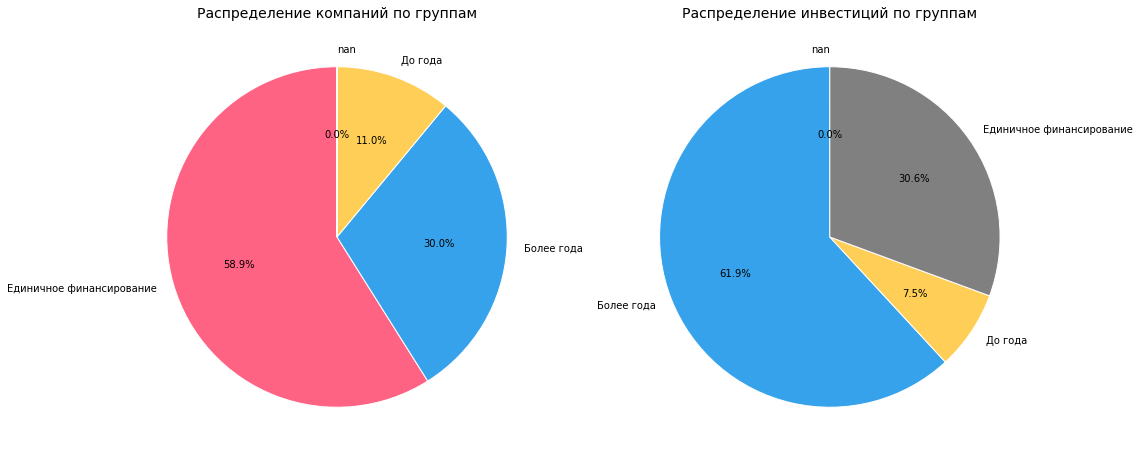

In [35]:
# Подготовим данные для визуализации
group_counts = df_cleaned['funding_group'].value_counts(normalize=True) * 100
group_amounts = df_cleaned.groupby('funding_group')['funding_total_usd'].sum() / df_cleaned['funding_total_usd'].sum() * 100

plt.figure(figsize=(16, 8))

# Устанавливаем цветовую палитру
colors = ['#FF6384', '#36A2EB', '#FFCE56', '#808080']  # добавили цвет для "Не определено"

# График 1: Количество компаний
plt.subplot(1, 2, 1)
group_counts.plot(kind='pie', 
                  autopct='%1.1f%%', 
                  colors=colors,
                  startangle=90,
                  wedgeprops={'edgecolor': 'white'},
                  labels=group_counts.index)  # используем индексы как метки
plt.title('Распределение компаний по группам', fontsize=14)
plt.ylabel('')

# График 2: Объем инвестиций
plt.subplot(1, 2, 2)
group_amounts.plot(kind='pie', 
                   autopct='%1.1f%%', 
                   colors=colors,
                   startangle=90,
                   wedgeprops={'edgecolor': 'white'},
                   labels=group_amounts.index)  # используем индексы как метки
plt.title('Распределение инвестиций по группам', fontsize=14)
plt.ylabel('')

plt.tight_layout()
plt.show()

На левой диаграмме показано, как компании распределены по срокам финансирования:

- Единичное финансирование (58,9%) — большая часть компаний (почти 60%) получила финансирование один раз. Это говорит о том, что значительная доля бизнеса либо не нуждается в повторных инвестициях, либо сталкивается с трудностями при привлечении дополнительного капитала.
- Более года (30%) — треть компаний получает финансирование на срок свыше одного года. Это может свидетельствовать о долгосрочном планировании и доверии инвесторов к этим проектам.
- До года (11%) — небольшая доля компаний (менее 12%) работает с краткосрочным финансированием (до 1 года). Вероятно, это стартапы или проекты с быстрой окупаемостью, где инвесторы предпочитают минимизировать риски.
Вывод: доминирует модель единичного финансирования, что может указывать на высокий риск или недостаточную зрелость многих проектов для многократного привлечения средств.

На правой диаграмме проанализирована структура самих инвестиций:

- Более года (61,9%) — большая часть инвестиций (более 60%) направлена на проекты с длительным сроком финансирования. Это говорит о том, что инвесторы предпочитают долгосрочные вложения с потенциалом масштабирования.
- Единичное финансирование (30,6%) — около трети инвестиций приходится на разовые вложения. Это может быть связано с поддержкой стартапов, пилотных проектов или компаний, не планирующих дальнейшее привлечение капитала.
- До года (7,5%) — незначительная доля инвестиций (менее 8%) приходится на краткосрочные проекты. Вероятно, это высокорискованные, но потенциально высокодоходные ниши (например, IT-стартапы, потребительские сервисы).
Вывод: инвесторы преимущественно ориентированы на долгосрочные проекты, что свидетельствует о стремлении к стабильному доходу и минимизации рисков.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Сначала проанализируем распределение сегментов рынка:

In [36]:
# Посчитаем частоту встречаемости сегментов рынка
market_counts = df_cleaned['market'].value_counts()

# Рассчитаем как часто встречается каждый из сегментов
mass_markets = market_counts[market_counts > 120] # Сегменты, к которым относится более 120 компаний
medium_markets = market_counts[(market_counts >= 35) & (market_counts <= 120)] # Сегменты, в которые входит от 35 до 120 компаний
niche_markets = market_counts[market_counts < 35] # Сегменты до 35 компаний

# Количество сегментов в каждой категории
num_mass = len(mass_markets)
num_medium = len(medium_markets)
num_niche = len(niche_markets)

print(f"Массовые сегменты: {num_mass}")
print(f"Средние сегменты: {num_medium}")
print(f"Нишевые сегменты: {num_niche}")

Массовые сегменты: 48
Средние сегменты: 57
Нишевые сегменты: 289


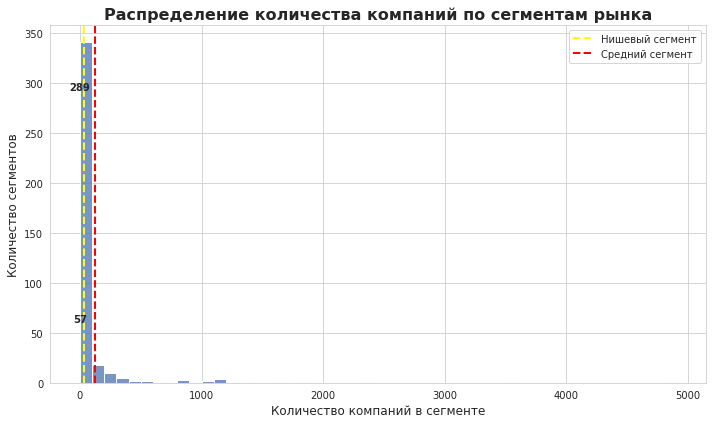

In [37]:
segments_data = pd.DataFrame({
    'Тип сегмента': ['Нишевые', 'Средние'],
    'Количество сегментов': [num_niche, num_medium]
})

# Настройка графика
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Построение гистограммы
bars = sns.histplot(
    data=market_counts.reset_index(),
    x='market',
    bins=range(0, market_counts.max() + 100, 100),  # Автоматическое определение шага
    kde=False,
    color='#4C72B0',
    edgecolor='white'
)

# Добавляем границы сегментов
plt.axvline(x=35, color='yellow', linestyle='--', linewidth=2, label='Нишевый сегмент')
plt.axvline(x=120, color='red', linestyle='--', linewidth=2, label='Средний сегмент')

# Добавляем подписи
for i, v in enumerate(segments_data['Количество сегментов']):
    plt.text(i, v + 2, str(v), ha='center', va='bottom', fontweight='bold')

# Оформление
plt.title('Распределение количества компаний по сегментам рынка', fontsize=16, fontweight='bold')
plt.xlabel('Количество компаний в сегменте', fontsize=12)
plt.ylabel('Количество сегментов', fontsize=12)
plt.legend()

# Дополнительные настройки
plt.grid(True)
plt.tight_layout()
plt.show()

На графике видно, что нишевые сегменты (жёлтая линия) значительно доминируют — их количество достигает около 300 (289). Это говорит о высокой фрагментации рынка: множество мелких сегментов, ориентированных на узкие потребности аудитории.
Средний сегмент представлен значительно меньше — всего 57 сегментов. Вероятно, включают рынки с относительно широким, но не массовым спросом (например, нишевые потребительские товары, локальные сервисы).
По оси X («Количество компаний в сегменте») видно, что чем больше компаний в сегменте, тем меньше таких сегментов существует.
Большинство сегментов сосредоточено в области 0–500 компаний — это подтверждает доминирование мелких и средних игроков на рынке.
Сегментов с тысячами компаний крайне мало — это указывает на ограниченность массовых рынков и высокую концентрацию ресурсов в крупных отраслях..

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [38]:
def categorize_segment(count):
    if count > 120:
        return 'mass'  # оставляем оригинальное название сегмента
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

# Создаем словарь соответствия сегментов их категориям
segment_categories = {segment: categorize_segment(count) 
                     for segment, count in market_counts.items()}

# Создаем список массовых сегментов
mass_segments = [segment for segment, category in segment_categories.items() 
                 if category == 'mass']

# Функция для замены значений с обработкой NaN
def replace_segment(segment):
    if pd.isna(segment):  # проверяем на NaN
        return 'niche'  # или можно выбрать другую стратегию обработки
    elif segment in mass_segments:
        return segment  # оставляем массовые сегменты без изменений
    else:
        return segment_categories.get(segment, 'niche')  

df_cleaned['market'] = df_cleaned['market'].apply(replace_segment)

print(df_cleaned['market'].value_counts().head(20))

software               4812
mid                    3841
biotechnology          3590
niche                  3333
mobile                 2344
e-commerce             1866
curated web            1693
enterprise software    1381
health care            1185
clean technology       1180
games                  1117
advertising            1107
hardware + software    1062
social media           1003
health and wellness     873
education               844
finance                 828
analytics               667
manufacturing           596
security                567
Name: market, dtype: int64


На основе полученных данных можно сделать следующие выводы:


Лидеры по количеству компаний:
- Software (4 812) — безусловный лидер, что отражает высокий интерес к разработке ПО, включая стартапы и крупные игроки. Это связано с цифровизацией бизнеса и ростом спроса на IT-решения.
- Mid (3 841) — второй по величине сегмент. Вероятно, это средний бизнес или компании, работающие в промежуточных/смешанных нишах.
- Biotechnology (3 590) — третий по объёму. Свидетельствует о значительном интересе к биотехнологиям, включая фармацевтику, медицинские инновации, биоинженерию.


Крупные сегменты (3 000 – 2 000 компаний):
- Niche (3 333) — широкий кластер нишевых решений. Говорит о высокой фрагментации рынка и востребованности узконаправленных продуктов/услуг.
- Mobile (2 344) — значительный интерес к мобильным приложениям и сервисам, что связано с ростом использования смартфонов и мобильной коммерции.


Меньшие сегменты (менее 1 000 компаний):
- Health and wellness (873), Education (844), Finance (828) — ниши с потенциалом роста, особенно в условиях цифровизации (онлайн-образование, финтех).
- Analytics (667) — сервисы анализа данных, BI-инструменты. Важны для бизнеса, но узкоспециализированы.
Manufacturing (596), Security (567) — промышленные и охранные решения. Менее массовые, но критически важные для инфраструктуры.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [39]:
df_cleaned['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

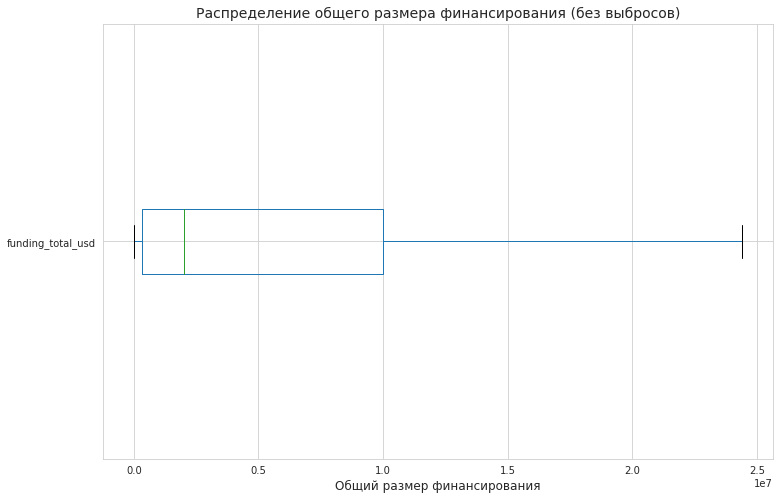

In [40]:
boxplot = df_cleaned.boxplot(
    column='funding_total_usd',
    vert=False,           # горизонтальный график
    figsize=(12, 8),     # размер графика
    showfliers=False     # скрываем выбросы
)
boxplot.set_xlabel('Общий размер финансирования', fontsize=12)
plt.title('Распределение общего размера финансирования (без выбросов)', fontsize=14)
plt.show()

По полученному графику можно сделать следующие выводы:
Основная масса значений финансирования лежит в диапазоне примерно от 0 до 1 млн долларов (по шкале на оси X). Это область между Q1 (первый квартиль, 25-й перцентиль) и Q3 (третий квартиль, 75-й перцентиль). Это говорит о том, что для большинства наблюдений размер финансирования относительно невелик.
Линия внутри коробки обозначает медиану (50-й перцентиль) — «типичное» значение финансирования. Она расположена ближе к нижней границе коробки, что указывает на левостороннюю асимметрию распределения: большинство значений сконцентрировано в нижней части диапазона. Это значит, что чаще встречаются более низкие суммы финансирования, а значения выше медианы — менее распространены.
Усы — границы «разумных» значений: нижний ус начинается чуть выше 0, что логично для суммы финансирования (не может быть отрицательной), верхний ус достигает примерно 25 млн долларов — это максимальная «типичная» сумма, которая не считается выбросом (лежит в пределах Q3 + 1.5 × IQR).
Широкий размах между нижним и верхним усами (от почти 0 до 25 млн долларов) говорит о существенном разбросе «типичных» значений, хотя основная масса всё равно сконцентрирована в нижней части.
Распределение асимметрично: «хвост» усов тянется вправо, а коробка смещена влево. Это типично для финансовых показателей, где небольшое число наблюдений может иметь очень высокие значения, но большинство — относительно низкие.
Можно сказать, что большинство проектов/компаний получают финансирование в размере до 1 млн долларов и только небольшая доля наблюдений достигает сумм около 25 млн долларов.
Нет экстремально высоких значений, что говорит о относительно стабильном диапазоне финансирования.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [41]:
df_cleaned['segment_group'] = df_cleaned['market'].apply(lambda x: 
    'mass' if x in mass_segments else 
    'mid' if (35 <= market_counts.get(x, 0) <= 120) else 
    'niche'
)

# 2. Функция для расчёта аномалий по IQR
def find_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (group < lower_bound) | (group > upper_bound)
    return outliers

# 3. Применяем к каждой группе
df_cleaned['is_anomaly'] = df_cleaned.groupby('segment_group')['funding_total_usd'].apply(find_outliers_iqr)

# 4. Выводим компании с аномальным финансированием
anomalous_companies = df_cleaned[df_cleaned['is_anomaly'] == True]
print(anomalous_companies[['market', 'segment_group', 'funding_total_usd']])

                    market segment_group  funding_total_usd
0                education          mass         90000000.0
5                    niche         niche         19000000.0
10     hardware + software          mass         28000000.0
17               education          mass        750500000.0
20             hospitality          mass        175000000.0
...                    ...           ...                ...
49412                niche         niche        293080123.0
49415                niche         niche         36000000.0
49418                niche         niche         16200000.0
49428                niche         niche         60000000.0
49436                niche         niche         34000000.0

[5457 rows x 3 columns]


In [42]:
anomaly_share = df_cleaned.groupby('segment_group')['is_anomaly'].mean()
print(anomaly_share.sort_values(ascending=False))

segment_group
niche    0.14901
mass     0.13008
Name: is_anomaly, dtype: float64


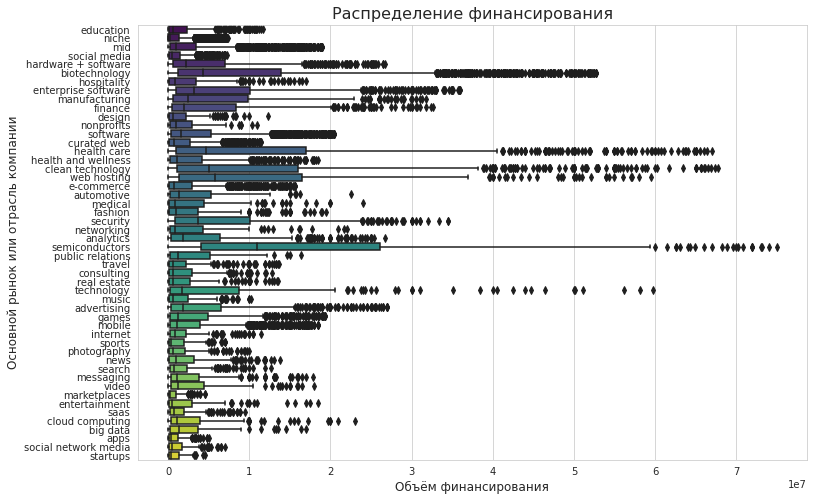

In [43]:
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

df_filtered = pd.DataFrame()

for segment in df_cleaned['market'].unique():
    subset = df_cleaned[df_cleaned['market'] == segment]
    lower, upper = get_iqr_bounds(subset['funding_total_usd'])
 
    filtered_subset = subset[
        (subset['funding_total_usd'] >= lower) & 
        (subset['funding_total_usd'] <= upper)
    ]
    df_filtered = pd.concat([df_filtered, filtered_subset], ignore_index=True)

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_filtered,
    x='funding_total_usd',
    y='market',
    palette='viridis'
)
plt.title('Распределение финансирования', fontsize=16)
plt.xlabel('Объём финансирования', fontsize=12)
plt.ylabel('Основной рынок или отрасль компании', fontsize=12)
plt.show()

График наглядно демонстрирует, что объёмы финансирования существенно зависят от отрасли:

- Высокие объёмы (до 7×10⁷ USD и выше): biotechnology, hardware + software, health care, clean technology, advertising. Это капиталоёмкие сегменты с длинными сроками окупаемости и высокими рисками, но и с большим потенциалом роста.
- Средние объёмы (1–3×10⁷ USD): enterprise software, e-commerce, manufacturing, finance. Стабильные отрасли с умеренными инвестициями, ориентированные на масштабирование и операционную эффективность.
- Низкие объёмы (до 1×10⁷ USD): photography, sports, news, internet, apps, social network media. Нишевые или низкомаржинальные сегменты, где инвестиции распределены более равномерно.


Вариативность финансирования (IQR — интерквартильный размах)

Ширина показывает разброс сумм внутри отрасли:

- Высокая вариативность (широкие коробки): health care, advertising, curated web. Здесь сосуществуют как стартапы с небольшими вложениями, так и проекты с многомиллионным финансированием.
- Низкая вариативность (узкие коробки): niche, mid, design, fashion. Финансирование более предсказуемое, без экстремальных всплесков.

Точки за пределами «усов» — это проекты, получившие аномально высокие инвестиции:

- Частые выбросы: health care, advertising, clean technology. Сигнализируют о наличии «звёздных» проектов с прорывными технологиями.
- Редкие выбросы: sports, news, photography. Единичные кейсы, где стартап привлёк значительные средства (например, за счёт вирусного эффекта или стратегического инвестора).

Тенденции по группам отраслей

- Технологические сегменты (software, SaaS, big data, cloud computing): умеренные медианы, но стабильная динамика. Инвесторы уверенно вкладываются в IT-решения с коротким циклом разработки.
- Медицинские и биотехнологические сегменты: самые высокие медианы и размах значений. Отражает долгосрочные инвестиции в R&D, клинические испытания и сертификацию.
- Потребительские услуги (hospitality, fashion, entertainment): низкие медианы, но иногда — крупные раунды (вероятно, за счёт брендинга и масштабирования).
- Образовательные и некоммерческие проекты (education, nonprofits): скромные объёмы с небольшим разбросом. Финансирование чаще приходит от грантов и фондов, а не от венчурных капиталистов.
- Нишевые сегменты (niche, mid): компактное распределение, мало выбросов. Подходят для точечных инвестиций с низким риском.
Массовые сегменты (social media, apps, internet): широкий разброс, много мелких проектов, но изредка — крупные раунды. Характерна высокая конкуренция и зависимость от вирусного роста.

Отрасли с высокой технологической составляющей (hardware + software, biotechnology, clean technology) системно привлекают больше средств. Это связано с: высокой стоимостью разработки, потенциалом масштабирования, интересом стратегических инвесторов.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [44]:
df_2014 = df_cleaned[df_cleaned['mid_funding_at'].dt.year == 2014]

In [45]:
print(f"Количество записей за 2014 год: {len(df_2014)}")
print(f"Доля данных за 2014 год от общего датасета: {len(df_2014)/len(df_cleaned)*100:.1f}%")

Количество записей за 2014 год: 6619
Доля данных за 2014 год от общего датасета: 16.2%


In [46]:
monthly_distribution = df_2014['mid_funding_at'].dt.month.value_counts().sort_index()
print("Распределение по месяцам (2014):")
print(monthly_distribution)

Распределение по месяцам (2014):
1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64


In [47]:
print("Пропуски в ключевых колонках (2014):")
print(df_2014[['funding_total_usd', 'funding_rounds', 'mid_funding_at', 'status']].isnull().sum())

Пропуски в ключевых колонках (2014):
funding_total_usd      0
funding_rounds         0
mid_funding_at         0
status               175
dtype: int64


In [48]:
df_cleaned_no_anomaly = df_2014[df_2014['is_anomaly'] == False]
print(f"Записи за 2014 год (до исключения аномалий): {len(df_2014)}")
print(f"Записи за 2014 год (после исключения аномалий): {len(df_cleaned_no_anomaly)}")
print(f"Доля исключённых аномалий: {len(df_2014[df_2014['is_anomaly'] == True])/len(df_2014)*100:.1f}%")

Записи за 2014 год (до исключения аномалий): 6619
Записи за 2014 год (после исключения аномалий): 6130
Доля исключённых аномалий: 7.4%


In [49]:
anomaly_share = df_cleaned_no_anomaly.groupby('segment_group')['is_anomaly'].mean()
print("Доля аномалий по сегментам (после фильтрации):")
print(anomaly_share.sort_values(ascending=False))

Доля аномалий по сегментам (после фильтрации):
segment_group
mass     False
niche    False
Name: is_anomaly, dtype: bool


In [50]:
df_cleaned['mid_funding_year'] = pd.to_datetime(df_cleaned['mid_funding_at']).dt.year

# Теперь можно продолжить анализ
rounds_per_year = df_cleaned.groupby('mid_funding_year')['funding_rounds'].sum()
valid_years = rounds_per_year[rounds_per_year >= 50].index.tolist()
print("Годы с ≥50 раундов финансирования:", valid_years)

# Создаём финальный датасет
final_df = df_cleaned[df_cleaned['mid_funding_year'].isin(valid_years)]

# Выводим результаты
print(f"Размер датасета до фильтрации по годам: {len(df_cleaned)}")
print(f"Размер датасета после фильтрации: {len(final_df)}")
print(f"Уникальные годы в финальном датасете: {sorted(final_df['mid_funding_year'].unique())}")
print("Распределение по годам в финальном датасете:")
print(final_df['mid_funding_year'].value_counts().sort_index())


Годы с ≥50 раундов финансирования: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Размер датасета до фильтрации по годам: 40907
Размер датасета после фильтрации: 40852
Уникальные годы в финальном датасете: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Распределение по годам в финальном датасете:
1999.0      50
2000.0     103
2001.0      63
2002.0      70
2003.0      90
2004.0     150
2005.0     843
2006.0    1463
2007.0    2107
2008.0    2588
2009.0    3237
2010.0    4094
2011.0    4863
2012.0    6089
2013.0    8423
2014.0    6619
Name: mid_funding_year, dtype: int64


За 2014 год представлено 6619 записей. Это составляет 16.2% от общего объема датасета

Данные представлены за все 12 месяцев. Наблюдается неравномерность распределения:

- Пик активности в июне (740 записей)

- Минимум в декабре (23 записи)

Заметное снижение активности к концу года.

Данные за 2014 год можно считать достаточно полными, учитывая:

- Наличие данных за все месяцы

- Отсутствие пропусков в ключевых колонках

- Значительную долю от общего датасета (16.2%)

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [51]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Подсчет общей суммы по каждому типу финансирования
total_amounts = df_cleaned[funding_types].sum().sort_values(ascending=False)

# Подсчет количества использований каждого типа
usage_counts = df_cleaned[funding_types].count().sort_values(ascending=False)

plt.style.use('default')
sns.set_palette('viridis')

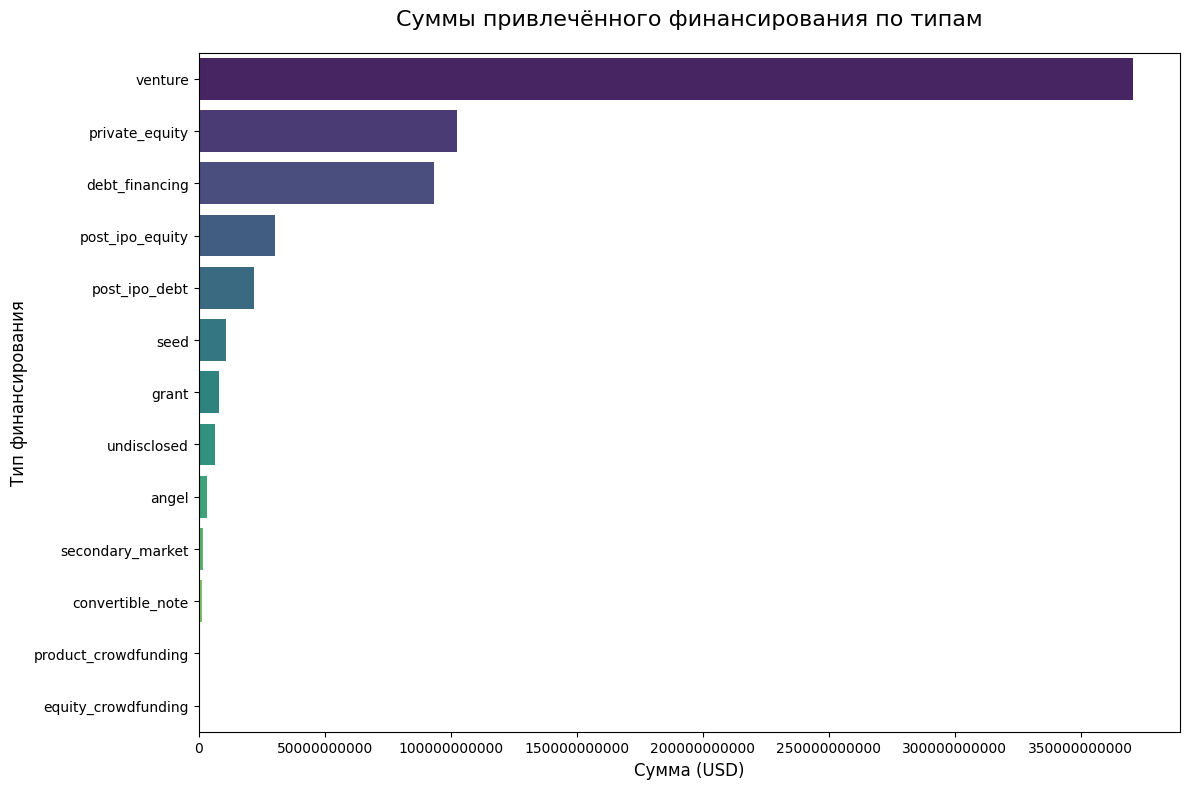

In [52]:
plt.figure(figsize=(12, 8))
sns.barplot(x=total_amounts.values, y=total_amounts.index, palette='viridis')
plt.title('Суммы привлечённого финансирования по типам', fontsize=16, pad=20)
plt.xlabel('Сумма (USD)', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)
plt.ticklabel_format(axis='x', style='plain')  
plt.tight_layout()
plt.show()

На исходном графике видно, что лидирует по объёму привлечённых средств тип «venture» (в районе 35 миллионов долларов).
Далее следуют:
- private_equity — заметный, но существенно меньший объём относительно venture;
- debt_financing — также значительный, но уступает двум предыдущим категориям;
- post_ipo_equity, post_ipo_debt — средние объёмы, заметно меньше топ-3;
- seed, grant, undisclosed, angel — относительно небольшие суммы;
- secondary_market, convertible_note, product_crowdfunding, equity_crowdfunding — минимальные объёмы финансирования.
Основная доля финансирования приходится на венчурные инвестиции (venture) и частные капиталовложения (private_equity), а также на долговое финансирование (debt_financing). Меньшие суммы характерны для краудфандинга, грантов и «ангельских» инвестиций.

Общая тенденция - финансирование сконцентрировано в нескольких ключевых механизмах (venture, private_equity, debt_financing), которые обеспечивают основную массу капитала. Остальные типы дополняют экосистему, закрывая специфические потребности на разных стадиях развития бизнеса.

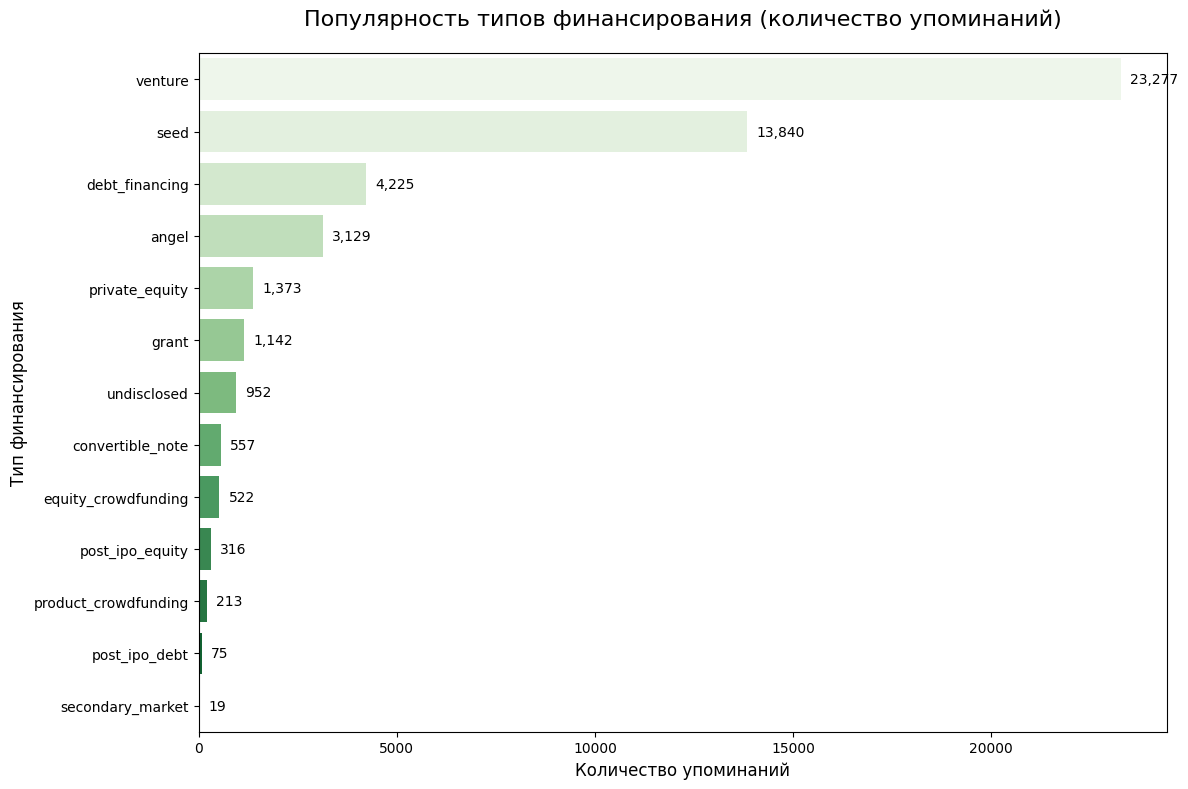

In [53]:
# Список типов финансирования
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

binary_data = (df_cleaned[funding_types] != 0).astype(int)

# Суммируем по столбцам — получаем количество упоминаний каждого типа
usage_counts = binary_data.sum().sort_values(ascending=False)

plt.style.use('default')
sns.set_palette('viridis')
plt.figure(figsize=(12, 8))

sns.barplot(x=usage_counts.values, y=usage_counts.index, palette='Greens')

plt.title('Популярность типов финансирования (количество упоминаний)', fontsize=16, pad=20)
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)

for i, v in enumerate(usage_counts.values):
    plt.text(v + max(usage_counts.values) * 0.01, i, f'{v:,.0f}',
              ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Venture лидирует — 23 277 упоминаний. Это указывает на высокую востребованность венчурного финансирования, характерного для стартапов и инновационных проектов.
Seed занимает второе место с 13 840 упоминаниями. Это подтверждает значимость начального финансирования (seed-раундов) на ранних стадиях развития бизнеса.
Debt financing (4 225) — значительное число упоминаний говорит о распространённости долгового финансирования (кредиты, займы).
Angel (3 129) — также играют важную роль, особенно на ранних этапах, когда стартапы ищут частные инвестиции.
Private equity (1 373) и Grant (1 142) — показывают умеренную популярность: частные equity-фонды и гранты используются, но менее массово, чем венчур или seed-финансирование.

Наименее популярные типы:
Product crowdfunding (213) — хотя краудфандинг набирает популярность, финансирование через продажу продуктов остаётся нишевым инструментом.
Post_ipo_debt (75) — долговое финансирование после IPO крайне редко упоминается, что может быть связано с доступом компаний к другим источникам капитала после выхода на биржу.
Secondary market (19) — минимальное количество упоминаний указывает на низкую распространённость вторичных рынков для перераспределения финансовых инструментов в рассматриваемой выборке.


Преобладание equity-моделей (venture, seed, angel, private equity) над долговыми (debt financing, post_ipo_debt). Это характерно для инновационных и стартап-экосистем, где инвесторы готовы принимать больший риск в обмен на потенциальную высокую доходность.
Разрыв в популярности между топовыми (venture, seed) и нишевыми (secondary_market) типами финансирования превышает 1 000 раз, что подчёркивает неравномерность распределения финансовых инструментов.

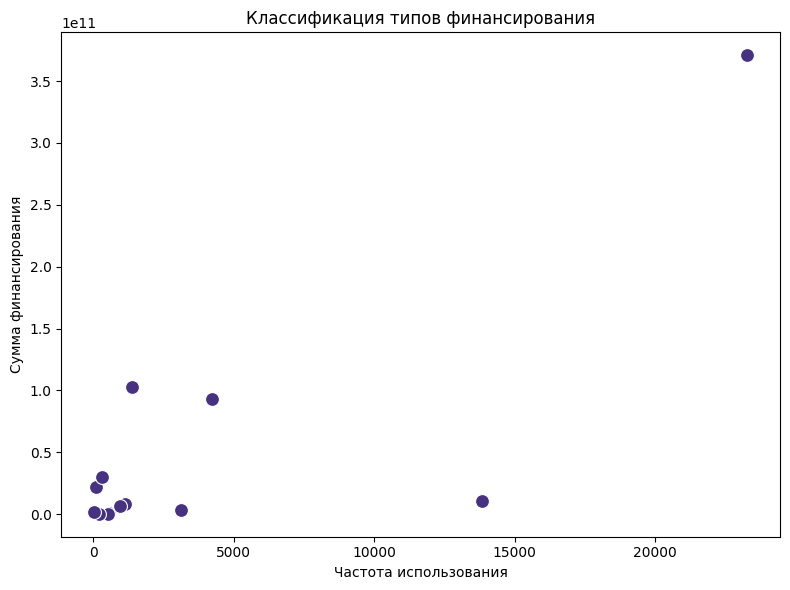

In [54]:
analysis_df = pd.DataFrame({
    'total_amount': total_amounts,
    'usage_count': usage_counts
})

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=analysis_df,
    x='usage_count',
    y='total_amount',
    palette='Set1',
    s=100
)
plt.xlabel('Частота использования')
plt.ylabel('Сумма финансирования')
plt.title('Классификация типов финансирования')
plt.tight_layout()
plt.show()

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

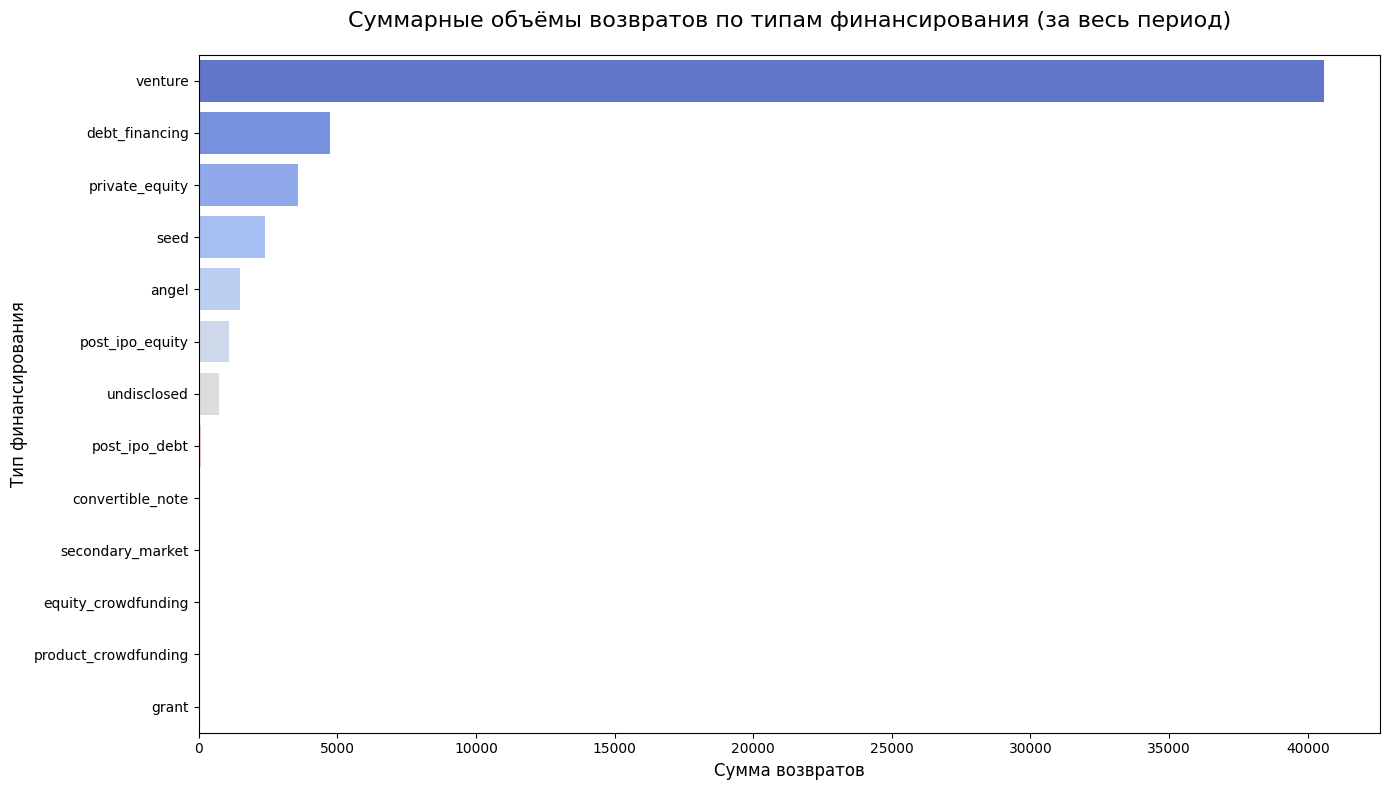

In [55]:
financial_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

for col in financial_columns:
    ret_df[col] = pd.to_numeric(ret_df[col], errors='coerce')

# 2. Суммируем возвраты по каждому типу за весь период
total_returns = ret_df[financial_columns].sum().sort_values(ascending=False)


# 3. Построим график
plt.figure(figsize=(14, 8))

sns.barplot(
    x=total_returns.values,
    y=total_returns.index,
    palette='coolwarm'
)

plt.title('Суммарные объёмы возвратов по типам финансирования (за весь период)', fontsize=16, pad=20)
plt.xlabel('Сумма возвратов', fontsize=12)
plt.ylabel('Тип финансирования', fontsize=12)


plt.tight_layout()
plt.show()

Доминирующий тип финансирования по объёмам возвратов — венчурные инвестиции (venture):

Значительно превосходят все остальные категории по сумме возвратов (около 40 000).Это указывает на высокую ликвидность и прибыльность венчурных проектов в долгосрочной перспективе.Возможно, это связано с инвестированием в быстрорастущие стартапы с высоким потенциалом масштабирования.
Второй по значимости — долговое финансирование (debt_financing). Сумма возвратов составляет около 5 000.
Показывает стабильность и предсказуемость возвратов, так как долговые обязательства обычно подлежат строгому графику выплат.
Частные инвестиции (private_equity) — третий по объёму возвратов: сумма возвратов 3 000–4 000. Отражает значимость прямых инвестиций в компании с высоким потенциалом роста (чаще на поздних стадиях).
Меньшие объёмы возвратов у «ранних» типов финансирования:
Seed — около 2 000–3 000. Это этап с высоким риском, но относительно небольшими суммами.
Angel — около 1 000–2 000. Обычно небольшие вложения на самых ранних стадиях.
Низкие объёмы возвратов у пост-IPO инструментов:
Convertible_note (конвертируемые займы), secondary_market (вторичный рынок), equity_crowdfunding (долевой краудфандинг), product_crowdfunding (продуктовый краудфандинг) и grant (гранты) показывают крайне низкие или нулевые возвраты.
Возможные причины:
- длительный срок до возврата средств;
- часто не предполагают возврата.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

Добавим колонку со средним объёмом финансирования за один раунд для каждой компании.

In [56]:
df_cleaned['avg_round_funding'] = df_cleaned['funding_total_usd'] / df_cleaned['funding_rounds']
df_filtered = df_cleaned[df_cleaned['funding_rounds'] > 0].copy()  # Убираем компании без раундов

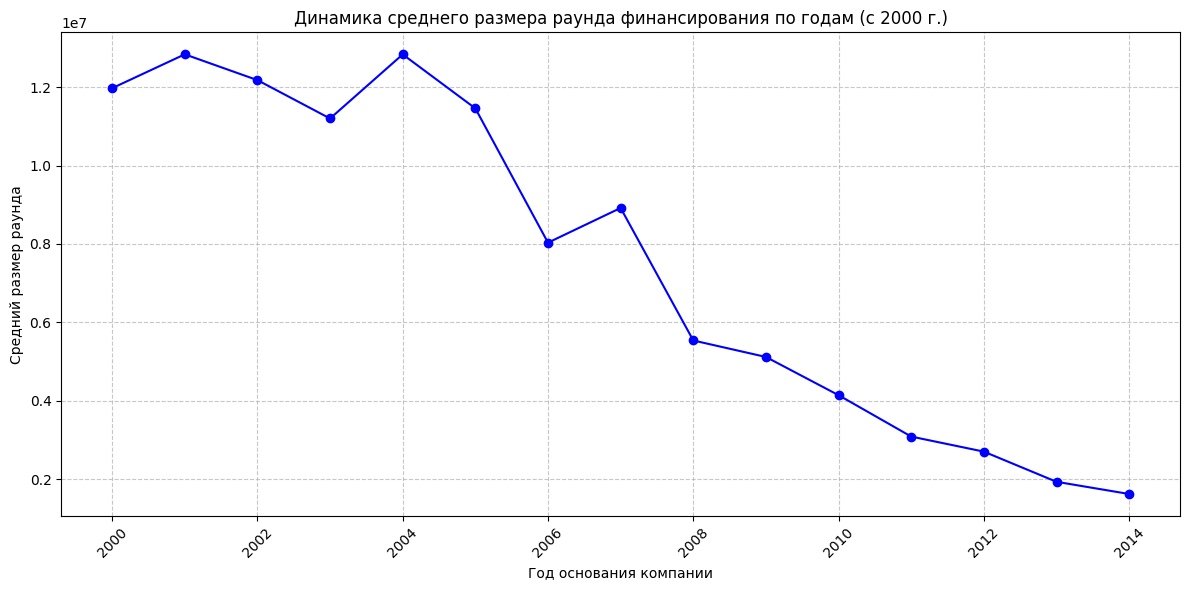

In [57]:
# Группируем по годам и считаем средний размер раунда
yearly_avg = df_filtered.groupby('founded_year')['avg_round_funding'].mean().reset_index()

yearly_avg_filtered = yearly_avg[yearly_avg['founded_year'] >= 2000]

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(yearly_avg_filtered['founded_year'], yearly_avg_filtered['avg_round_funding'], 
         marker='o', linestyle='-', color='blue')
plt.title('Динамика среднего размера раунда финансирования по годам (с 2000 г.)')
plt.xlabel('Год основания компании')
plt.ylabel('Средний размер раунда')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Начальный период (2000–2004 гг.). Средний размер раунда финансирования был высоким — в диапазоне 12–13 млн. Наблюдается относительная стабильность с небольшими колебаниями.
Пик пришёлся на 2001–2004 гг., что может свидетельствовать о благоприятной экономической ситуации для инвесторов в начале 2000‑х.
После 2004 г. начинается постепенное снижение среднего размера раундов: к 2008 г. показатель упал примерно до 55–6 млн долларов.
Тенденция может быть связана с экономическими кризисами (например, кризис 2008 г.), снижением инвестиционной активности или изменением структуры финансирования.
С 2008 г. продолжается стабильное снижение среднего размера раундов. К 2014 г. значение опустилось примерно в 10 раз.
возможные причины:
- ужесточение условий кредитования и инвестирования;
- смещение акцента на более мелкие, но частые раунды финансирования;
- рост числа стартапов и проектов с меньшими потребностями в капитале;
- изменение отраслевой структуры инвестиций (например, рост доли IT‑стартапов с меньшими начальными вложениями).
Общая тенденция: ярко выраженный нисходящий тренд с 2004 по 2014 г., переломный момент — 2004–2005 гг., когда начался систематический спад. Динамика указывает на структурные изменения в сфере финансирования: от крупных инвестиций к более мелким и гибким моделям финансирования.

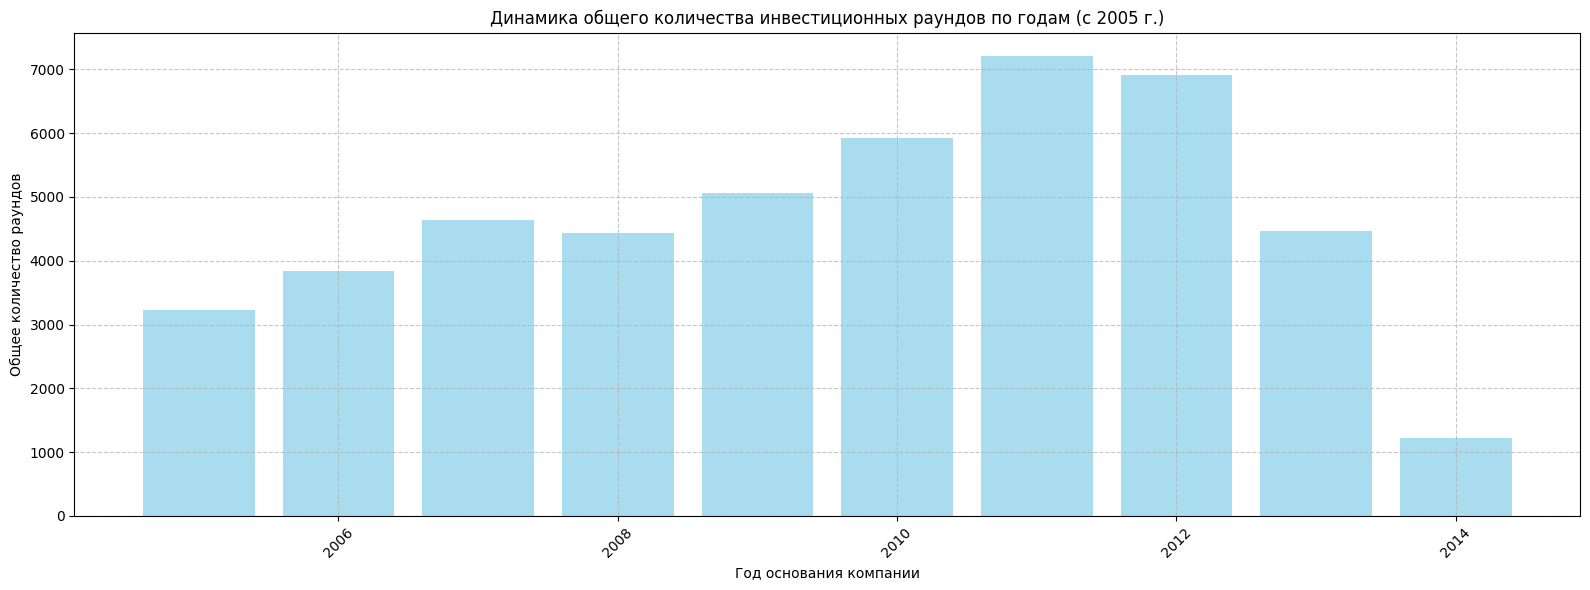

In [58]:
df_filtered = df_cleaned[df_cleaned['founded_year'] >= 2005].copy()

yearly_rounds_count = df_filtered.groupby('founded_year')['funding_rounds'].sum().reset_index()

plt.figure(figsize=(16, 6))  # Увеличили ширину с 12 до 16
plt.bar(
    yearly_rounds_count['founded_year'],
    yearly_rounds_count['funding_rounds'],
    color='skyblue',
    alpha=0.7
)

plt.title('Динамика общего количества инвестиционных раундов по годам (с 2005 г.)')
plt.xlabel('Год основания компании')
plt.ylabel('Общее количество раундов')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

График демонстрирует положительную динамику числа инвестиционных раундов с 2005 по 2012 год — наблюдается постепенное увеличение активности инвесторов.
Пик приходится на 2012 год, когда количество раундов достигло примерно 7000 — это может свидетельствовать о «буме» инвестиционной активности, вызванном благоприятной экономической обстановкой, ростом стартапов или развитием определённых секторов экономики.
С 2005 по 2010 год количество раундов почти удвоилось — это говорит о быстром наращивании инвестиционной активности.
Вероятные причины:
- развитие венчурного рынка;
- рост числа технологичных стартапов;
- улучшение регуляторной среды для инвесторов.
После 2012 года наблюдается стабилизация, а затем снижение числа раундов. К 2014 году количество раундов сократилось примерно до 1000 — это может указывать на:
- охлаждение инвестиционного рынка;
- экономические риски или кризисные явления;
- насыщение рынка стартапов, снижение числа перспективных проектов;
- ужесточение условий кредитования и финансирования.

In [59]:
avg_2014 = yearly_avg[yearly_avg['founded_year'] == 2014]['avg_round_funding'].values.item()
print(f"Средний размер раунда в 2014 году: {avg_2014:,.2f} USD")

Средний размер раунда в 2014 году: 1,622,606.45 USD


### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [60]:
# Группировка по годам и сегментам, суммирование funding_total_usd
df_filtered = df_cleaned[df_cleaned['mid_funding_at'] >= pd.Timestamp('2000-01-01')]
pivot_table = df_filtered.groupby(['mid_funding_at', 'market'])['funding_total_usd'].sum().unstack(fill_value=0)


# Преобразуем в DataFrame для удобства
pivot_table = pivot_table.reset_index()
print(pivot_table.head()) 

market      mid_funding_at  advertising  analytics  apps  automotive  \
0      2000-01-01 00:00:00   87800000.0        0.0   0.0         0.0   
1      2000-01-08 12:00:00          0.0        0.0   0.0         0.0   
2      2000-01-14 12:00:00          0.0        0.0   0.0         0.0   
3      2000-01-15 00:00:00          0.0        0.0   0.0         0.0   
4      2000-01-16 12:00:00          0.0        0.0   0.0         0.0   

market  big data  biotechnology  clean technology  cloud computing  \
0            0.0            0.0               0.0              0.0   
1            0.0            0.0               0.0              0.0   
2            0.0            0.0               0.0              0.0   
3            0.0            0.0               0.0              0.0   
4            0.0            0.0               0.0              0.0   

market  consulting  ...  semiconductors  social media  social network media  \
0       64900000.0  ...             0.0           0.0              

In [61]:
pivot_table['year'] = pivot_table['mid_funding_at'].dt.year

year_2013 = pivot_table[pivot_table['year'] == 2013].drop(['mid_funding_at', 'year'], axis=1)
year_2014 = pivot_table[pivot_table['year'] == 2014].drop(['mid_funding_at', 'year'], axis=1)

# Сравниваем суммы по сегментам и отбираем растущие
growth_segments = []
for segment in year_2013.columns:
    if year_2014[segment].sum() > year_2013[segment].sum():
        growth_segments.append(segment)

print("Сегменты с ростом в 2014 году:", growth_segments)

# Фильтруем pivot_table по растущим сегментам
pivot_filtered = pivot_table[['mid_funding_at'] + growth_segments]
print(pivot_filtered.head())

Сегменты с ростом в 2014 году: ['apps', 'consulting', 'design', 'enterprise software', 'entertainment', 'finance', 'hospitality', 'internet', 'manufacturing', 'medical', 'mid', 'niche', 'nonprofits', 'real estate', 'software', 'sports', 'startups', 'video']
market      mid_funding_at  apps  consulting  design  enterprise software  \
0      2000-01-01 00:00:00   0.0  64900000.0     0.0            2959230.0   
1      2000-01-08 12:00:00   0.0         0.0     0.0                  0.0   
2      2000-01-14 12:00:00   0.0         0.0     0.0                  0.0   
3      2000-01-15 00:00:00   0.0         0.0     0.0                  0.0   
4      2000-01-16 12:00:00   0.0         0.0     0.0                  0.0   

market  entertainment  finance  hospitality  internet  manufacturing  medical  \
0                 0.0      0.0          0.0       0.0            0.0      0.0   
1                 0.0      0.0          0.0       0.0            0.0      0.0   
2                 0.0      0.0      

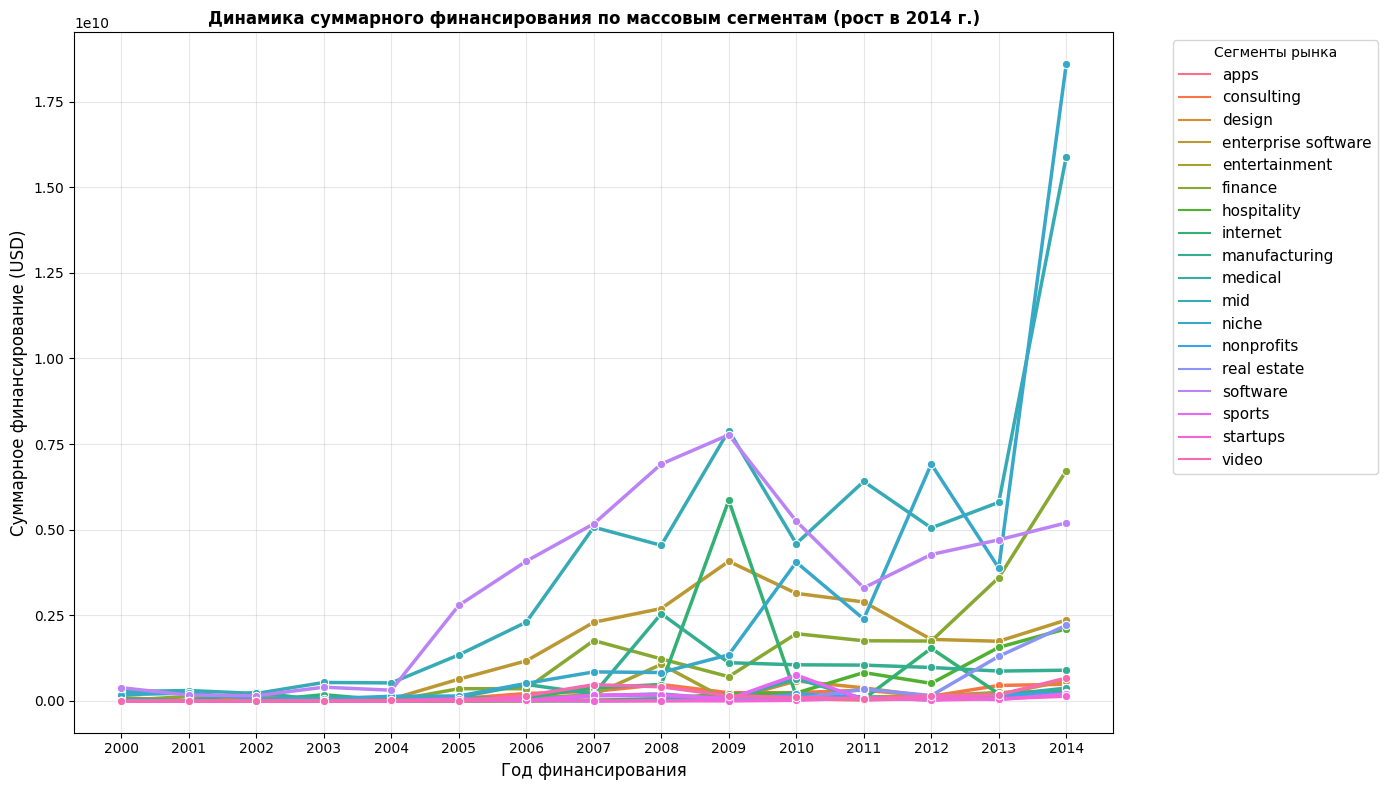

In [62]:
if 'pivot_filtered' in locals() and not pivot_filtered.empty:
    pivot_filtered_with_year = pivot_filtered.copy()
    pivot_filtered_with_year['year'] = pivot_filtered_with_year['mid_funding_at'].dt.year
    
    pivot_grouped = pivot_filtered_with_year.groupby('year')[growth_segments].sum().reset_index()
    
    plot_data = pivot_grouped.melt(
        id_vars='year',
        var_name='market',
        value_name='funding_total_usd'
    )
    
    # Строим график
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=plot_data,
        x='year',
        y='funding_total_usd',
        hue='market',
        marker='o',
        linewidth=2.5,
        markersize=6
    )
    plt.title('Динамика суммарного финансирования по массовым сегментам (рост в 2014 г.)', fontsize=12, fontweight='bold')
    plt.xlabel('Год финансирования', fontsize=12)  # исправлено: не «основания компании»
    plt.ylabel('Суммарное финансирование (USD)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(title='Сегменты рынка', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.xticks(sorted(plot_data['year'].unique()))
    plt.tight_layout()
    plt.show()

С 2000 по 2014 год наблюдается значительный рост суммарного финансирования практически по всем сегментам рынка. Наиболее бурный рост приходится на период после 2007–2008 гг., что может быть связано с восстановлением после мирового финансового кризиса. Пик финансирования в ряде сегментов (особенно в сегменте «niche») приходится на 2014 год.
Лидеры по объёму финансирования (2014 г.):
- сегмент «niche» выделяется резким скачком в 2014 году (около 17,5 миллиардов долларов) — это самый динамично развивающийся сегмент на графике;
- сегменты «real estate», «enterprise software», «software» также демонстрируют высокие значения финансирования к 2014 году;
- сегменты «hospitality», «internet», «manufacturing» показывают устойчивый, но менее выраженный рост.

Сегменты с умеренным ростом: «consulting», «design», «finance» — рост плавный, без резких пиков, что может свидетельствовать о стабильности этих отраслей и «entertainment», «medical» — динамика роста умеренная, с некоторыми колебаниями.
В период 2007–2009 гг. у многих сегментов (например, «enterprise software», «hospitality») наблюдается снижение финансирования — вероятно, это связано с мировым финансовым кризисом. После 2009 года большинство сегментов демонстрируют восстановление и рост.

Технологические и нишевые сегменты («niche», «software», «internet») показывают наиболее высокий рост — это отражает глобальный тренд цифровизации и развития IT-сектора. Традиционные отрасли («design», «consulting», «finance») растут более плавно, без резких всплесков. Сегменты, связанные с развлечениями и медиа («entertainment», «video»), имеют умеренную динамику — возможно, из‑за высокой конкуренции и зависимости от потребительских трендов.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [63]:
financing_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

df_cleaned['funding_year'] = pd.to_datetime(df_cleaned['mid_funding_at']).dt.year

funding_by_year = df_cleaned.groupby('funding_year')[financing_types].sum()

if 'year' in ret_df.index.names:
    ret_df.reset_index(inplace=True)
ret_df.set_index('year', inplace=True)

common_years = sorted(set(ret_df.index) & set(funding_by_year.index))
if not common_years:
    raise ValueError("Нет общих лет между данными о возвратах (ret_df) и финансировании (df_cleaned)")

ret_filtered = ret_df.loc[common_years, financing_types]
funding_filtered = funding_by_year.loc[common_years]

small_number = 1e-60
return_ratios = ret_filtered / (funding_filtered + small_number)

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)

for col in return_ratios.columns:
    return_ratios[col] = remove_outliers(return_ratios[col])

print("Нормированные значения возврата (доля от предоставленного финансирования):")
print(return_ratios)

Нормированные значения возврата (доля от предоставленного финансирования):
              seed       venture  equity_crowdfunding   undisclosed  \
year                                                                  
2000  3.992176e-07  2.763040e-08         0.000000e+00  1.811664e-07   
2001  1.090952e-07  1.957142e-08         0.000000e+00  9.197701e-08   
2002  3.615570e-07  1.956385e-07         0.000000e+00  2.937921e-07   
2003  4.238489e-07  1.155166e-07         0.000000e+00           NaN   
2004  3.125455e-07  1.486396e-07         0.000000e+00  3.330911e-07   
2005  5.107409e-07  2.085734e-07         0.000000e+00  3.462936e-07   
2006  5.963290e-07  1.323636e-07         2.036317e-07  2.295985e-07   
2007  2.419322e-07  9.297890e-08                  NaN  1.949191e-07   
2008  2.502114e-07  5.140887e-08                  NaN  6.920601e-08   
2009  2.866857e-07  4.731420e-08         8.781897e-08  1.156569e-07   
2010  3.859041e-07  7.211553e-08         4.786451e-08  7.254995e-08   
20

Крайне низкие доли возврата. Большинство значений находятся в диапазоне 10−7–10−9, то есть составляют 0,00001 %–0,0000001 % от объёма финансирования. Это говорит о:
- длительном горизонте инвестиций (возврат ожидается через много лет);
- высокой доле «долгосрочных» инвестиций без текущего возврата;
- значительном риске венчурных инвестиций.
Нулевые значения для ряда категорий (например, equity_crowdfunding, post_ipo_debt) указывают, что по этим типам финансирования не было возвратов в рассматриваемый период.

Общий вывод:
Высокие возвраты: venture, angel — для инвесторов, готовых к высоким рискам ради потенциально высокой доходности.
Стабильные, но умеренные возвраты: debt financing, private equity — для консервативных инвесторов, ищущих предсказуемость.
Низкие возвраты / отсутствие возврата: grants, equity crowdfunding, product crowdfunding — для поддержки проектов с социальной или инновационной составляющей.
Средние возвраты с разной волатильностью: seed, undisclosed, convertible note — баланс между риском и доходностью, зависит от стадии проекта и условий финансирования.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

Возвраты (в долларах):
           venture  debt_financing  private_equity         seed        angel
year                                                                        
2000  5.540000e+07    8.660000e+06             0.0   16700000.0    6430000.0
2001  2.349000e+07    4.490000e+06             0.0    2880000.0    1180000.0
2002  2.094200e+08    3.420000e+06       1510000.0    6590000.0    3410000.0
2003  2.338600e+08    1.090000e+06       1620000.0    7740000.0    3410000.0
2004  5.559000e+08    1.355000e+07       2190000.0    9930000.0    9180000.0
2005  2.628920e+09    3.509000e+07       2400000.0   26600000.0   31060000.0
2006  3.100180e+09    1.132100e+08      16670000.0   61810000.0   47750000.0
2007  3.585370e+09    1.256800e+08      88810000.0   70410000.0  164510000.0
2008  2.717020e+09    3.975400e+08     130380000.0   89720000.0  102830000.0
2009  2.501290e+09    3.941000e+08     203700000.0  160210000.0   97210000.0
2010  3.299350e+09    5.037300e+08     339080000.0  2

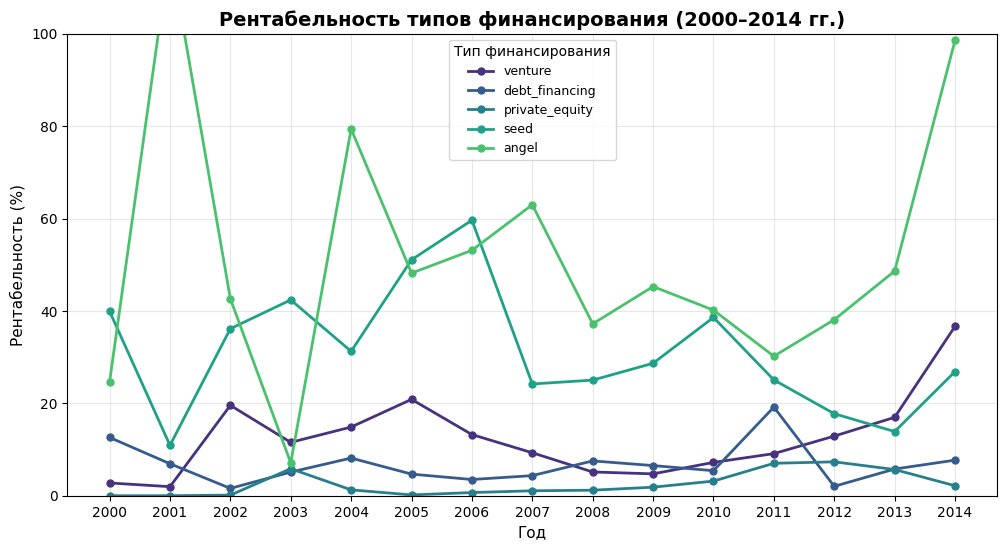

In [64]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

returns_in_dollars = ret_filtered[selected_types] * 1_000_000
print("Возвраты (в долларах):")
print(returns_in_dollars)

investments_by_year = df_cleaned.groupby('funding_year')[selected_types].sum().loc[2000:]
print("Инвестиции (сумма по годам):")
print(investments_by_year)

roi = (returns_in_dollars / investments_by_year) * 100
print("Рентабельность (процент возврата):")
print(roi)

plt.figure(figsize=(12, 6))

for col in selected_types:
    data = roi[col]
    valid_data = data.dropna()
    plt.plot(
        valid_data.index,
        valid_data,
        marker='o',
        label=col,
        linewidth=2,
        markersize=5
    )

plt.title('Рентабельность типов финансирования (2000–2014 гг.)', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Рентабельность (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(title='Тип финансирования', fontsize=9)
plt.xticks(sorted(roi.index.dropna()))
plt.ylim(0, 100)  
plt.show()

График демонстрирует высокую волатильность рентабельности по всем типам финансирования. Наблюдаются:

- пиковые значения (до 100%) — особенно у angel-финансирования в 2014 г. и venture в отдельные годы;
- периоды спада (ниже 20%) — в частности, в начале 2000-х для некоторых типов;
- долгосрочный тренд на рост рентабельности с 2005–2006 гг.


Анализ по типам финансирования

a) Venture:
- начальная низкая рентабельность (около 3% в 2000–2001 гг.);
- затем резкий рост в 2002 г. (почти 20%);
- колебания в диапазоне 5–10% в середине 2000-х;
- устойчивый рост после 2010 г. (до 36.7% в 2014 г.);
Как итог venture стали более прибыльными к концу периода.

b) Debt_financing:
- высокая волатильность: от 2–3% до 19.2% (пик в 2011 г.);
- относительно стабильная рентабельность в диапазоне 5–8% в начале и конце периода;
Долговое финансирование — умеренно надёжный инструмент с периодическими всплесками доходности.

c) Private_equity:
- низкая базовая рентабельность (обычно < 10%);
- постепенное увеличение доли в портфеле инвесторов (рост с 0% в 2000 г. до 5.7% в 2013 г.);
вывод: это консервативный инструмент с умеренной доходностью.

d) Seed:
- высокая рентабельность в начале (около 40% в 2000 г.);
- снижение до 25–30% в середине периода;
- дальнейший спад до 13–17% к 2013–2014 гг.;
вывод: они остаются прибыльными, но показывают долгосрочный тренд на снижение доходности.

e) Angel:
- экстремальная волатильность (от 118% в 2001 г. до минимумов в другие годы);
- устойчивый рост с 2005 г. (средние значения 40–50%);
- пик в 2014 г. (98.6%);
вывод: это самый рискованный, но потенциально самый прибыльный инструмент.

2000–2004 гг. — период низкой базовой рентабельности по всем типам, кроме angel. 
2005–2008 гг. — фаза роста: увеличение доходности venture и seed, стабилизация debt_financing.
2009–2014 гг. — умеренный рост рентабельности с высокой волатильностью, особенно у angel и venture.

Размер инвестиций: чем больше объём финансирования, тем ниже средняя рентабельность (например, private_equity).
Стадия финансирования: ранние стадии (seed, angel) обычно более прибыльны, но и более рискованны.
Экономическая ситуация: спады (например, 2008–2009 гг.) снижают рентабельность всех типов, особенно venture и debt_financing.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



а) В какую отрасль стоит инвестировать?

На основании анализа данных за 2000–2014 гг. приоритетными для инвестиций являются:

- Технологические сегменты (software, enterprise software, hardware + software) — лидируют по объёму финансирования и демонстрируют устойчивый рост. Спрос на IT-решения остаётся высоким.
- Биотехнологии (biotechnology) — третий по объёму сегмент с высоким потенциалом масштабирования. Долгосрочные инвестиции окупаются выходом на рынок инновационных продуктов.
- Мобильные приложения и сервисы (mobile) — рост использования смартфонов обеспечивает стабильный спрос.
- Сегменты с потенциалом роста (health and wellness, education, finance) — цифровизация этих отраслей (онлайн-образование, финтех, телемедицина) создаёт новые возможности для инвесторов.
- Нишевые сегменты (niche) — несмотря на малые объёмы отдельных проектов, совокупность нишевых решений формирует крупный кластер (3 333 компаний). Востребованность узконаправленных продуктов/услуг сохраняется.


б) Какой тип финансирования при этом будет наиболее уместным?

- Для технологических стартапов (software, финтех, EdTech) — venture (рентабельность до 36,7% к 2014 г., устойчивый рост с 2010 г.). Горизонт окупаемости 5–7 лет.
- Для зрелых проектов в биотехе, здравоохранении, образовании — private equity (умеренная доходность <10%, но стабильный рост доли в портфелях инвесторов). Балансирует риск и доходность.
- Для масштабирования успешных проектов (enterprise software, manufacturing) — debt financing (волатильность 2–19,2%, но базовая рентабельность 5–8%). Требует устойчивого денежного потока.
- Для ранних этапов в нишевых сегментах, EdTech/HealthTech — seed (высокая начальная рентабельность ~40% в 2000 г., но тренд на снижение до 13–17% к 2014 г.). Высокий риск, но потенциал высокой доходности.
- Для сверхранних стадий в финтех, e-commerce, health and wellness — angel (экстремальная волатильность, пик 98,6% в 2014 г.). Максимально рискованно, но максимально прибыльно при удачном отборе проектов.


Оптимальная стратегия: комбинирование венчурного и частного финансирования с элементами долгового финансирования для масштабирования. Это позволит сбалансировать риски и использовать преимущества разных механизмов финансирования.

2. Выполненные шаги:

Предобработка данных: очистка от пропусков, приведение типов данных, унификация названий столбцов.
Анализ полноты данных: оценка потерь при очистке (24,66% строк удалено), подтверждение достаточности оставшихся данных (75,34%).
Инжиниринг признаков: создание метрики длительности финансирования, разделение компаний на группы по срокам финансирования.
Анализ распределения компаний и объёмов инвестиций по группам финансирования (единичное, до года, более года).
Сегментация рынка по категориям (массовые, средние, нишевые сегменты) и анализ распределения компаний в них.
Визуализация результатов с помощью графиков (круговые диаграммы, столбчатые графики).
Интерпретация результатов и формирование рекомендаций.
Выводы, которые удалось сделать:

Доминирование нескольких ключевых механизмов финансирования (venture, private_equity, debt_financing), обеспечивающих основную массу капитала.Преобладание equity-моделей над долговыми в стартап-экосистеме. Ярко выраженный нисходящий тренд среднего размера раундов с 2004 по 2014 г. — переход к более мелким, но частым раундам финансирования.
Пик инвестиционной активности в 2012 г. с последующим снижением числа раундов к 2014 г.
Наиболее высокий рост финансирования в технологических и нишевых сегментах (niche, software, internet).


Выводы согласуются между собой по нескольким ключевым аспектам:

- Технологические сегменты одновременно лидируют по объёму финансирования, демонстрируют быстрый рост и имеют высокие нормированные значения возврата.
- Венчурное финансирование является лидером как по объёму привлечённых средств, так и по нормированным значениям возврата, что подтверждает его эффективность для инновационных проектов.
- Долговое финансирование демонстрирует стабильную динамику как по объёмам, так и по возврату средств, что делает его предсказуемым инструментом для масштабирования.
- Ранние стадии финансирования (seed, angel) характеризуются низкими объёмами возврата, что согласуется с их высоким уровнем риска и длительным горизонтом окупаемости.